# Step 1: Define the Use Case

## Student Feedback Classification

Student feedback plays an important role in improving the quality of teaching and learning. Educational institutions often collect feedback from students to understand their experiences, identify strengths, and highlight areas that need improvement. However, when a large number of students provide feedback, manually reading and analyzing every comment can become a time-consuming task.

The aim of this project is to develop a Student Feedback Classification system using Natural Language Processing (NLP) and Machine Learning techniques. The system will automatically analyze written student reviews and classify them as either Positive or Negative based on the sentiment expressed in the text.

For this project, I am using a dataset of student course reviews collected from an online learning platform. Each review is associated with a rating from 1 to 5. To create a binary classification problem, reviews with ratings of 1 and 2 are considered Negative, while reviews with ratings of 4 and 5 are considered Positive. Reviews with a rating of 3 are excluded because they represent neutral opinions and do not clearly belong to either category.

This classification system can help educational institutions quickly analyze large volumes of student feedback, identify common issues, measure student satisfaction, and support data-driven improvements in courses and teaching practices.

### Input

A written review or feedback comment provided by a student.

### Output

A sentiment label:

* Positive
* Negative

### Example

**Input:**
"The instructor explained difficult concepts clearly and the course content was very useful."

**Output:**
Positive

**Input:**
"The lectures were confusing and the assignments were not well explained."

**Output:**
Negative


Step 2: Dataset Exploration

In [3]:
import pandas as pd

df = pd.read_csv("../data/reviews.csv")

df.head()

,Id,Review,Label
0,0,good and interesting,5
1,1,"This class is very helpful to me. Currently, I...",5
2,2,like!Prof and TAs are helpful and the discussi...,5
3,3,Easy to follow and includes a lot basic and im...,5
4,4,Really nice teacher!I could got the point eazl...,4


In [4]:
print("Dataset Shape:", df.shape)

df.info()

Dataset Shape: (107018, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107018 entries, 0 to 107017
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Id      107018 non-null  int64 
 1   Review  107018 non-null  object
 2   Label   107018 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.4+ MB


In [5]:
df['Label'].value_counts()

,count
Label,
5,79173
4,18054
3,5071
1,2469
2,2251


In [6]:
df.isnull().sum()

,0
Id,0
Review,0
Label,0


#Step 2: Dataset Exploration

The dataset used in this project contains student course reviews collected from an online learning platform. Each review is associated with a rating ranging from 1 to 5, where higher ratings generally indicate a more positive learning experience.

After loading the dataset, I explored its structure and basic statistics. The dataset contains 107,018 records and 3 columns: `Id`, `Review`, and `Label`. The `Review` column contains the textual feedback provided by students, while the `Label` column contains the rating assigned to the review.

The dataset does not contain any missing values, which means no additional data cleaning is required for handling null entries.

### Dataset Statistics

* Total number of reviews: 107,018
* Number of features: 3
* Text column: Review
* Target column: Label
* Missing values: None

### Distribution of Ratings

| Rating | Number of Reviews |
| ------ | ----------------- |
| 1      | 2,469             |
| 2      | 2,251             |
| 3      | 5,071             |
| 4      | 18,054            |
| 5      | 79,173            |

The distribution shows that the dataset is highly imbalanced, with most reviews receiving ratings of 4 or 5. Since the objective of this project is to perform sentiment classification, the ratings will be converted into two classes. Ratings 1 and 2 will be labeled as Negative, while ratings 4 and 5 will be labeled as Positive. Reviews with a rating of 3 will be removed because they represent neutral opinions.

This transformation will simplify the problem into a binary classification task and make it easier to evaluate the performance of machine learning models.


In [7]:
# Remove neutral reviews
df = df[df['Label'] != 3]

# Convert ratings to sentiment labels
df['Sentiment'] = df['Label'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

# Check distribution
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,97227
Negative,4720


In [8]:
df[['Review', 'Sentiment']].head()

,Review,Sentiment
0,good and interesting,Positive
1,"This class is very helpful to me. Currently, I...",Positive
2,like!Prof and TAs are helpful and the discussi...,Positive
3,Easy to follow and includes a lot basic and im...,Positive
4,Really nice teacher!I could got the point eazl...,Positive


**Balancing dataset**
The original dataset was highly imbalanced. Therefore, a balanced subset was created by randomly sampling positive reviews while retaining all negative reviews.

In [9]:
# Separate positive and negative reviews
positive_df = df[df['Sentiment'] == 'Positive']
negative_df = df[df['Sentiment'] == 'Negative']

# Randomly sample positive reviews
positive_sample = positive_df.sample(
    n=len(negative_df),
    random_state=42
)

# Combine both classes
balanced_df = pd.concat(
    [positive_sample, negative_df],
    axis=0
)

# Shuffle the dataset
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

# Check class distribution
balanced_df['Sentiment'].value_counts()

,count
Sentiment,
Positive,4720
Negative,4720


In [10]:
balanced_df.shape

(9440, 4)

In [11]:
balanced_df.to_csv(
    'balanced_student_reviews.csv',
    index=False
)

In [13]:
from google.colab import files
files.download("balanced_student_reviews.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Handling Class Imbalance

After converting the ratings into Positive and Negative sentiment labels, the dataset was found to be highly imbalanced. Approximately 95% of the reviews belonged to the Positive class, while only about 5% belonged to the Negative class.

Class imbalance can negatively affect machine learning models because they may become biased toward the majority class and achieve high accuracy without properly learning the minority class. To address this issue, a balanced dataset was created by randomly sampling an equal number of Positive reviews and combining them with all available Negative reviews.

The final balanced dataset contains 4,720 Positive reviews and 4,720 Negative reviews, resulting in a total of 9,440 reviews. This balanced distribution allows for a fairer evaluation of different machine learning models and improves the reliability of performance metrics such as Precision, Recall, and F1-score.

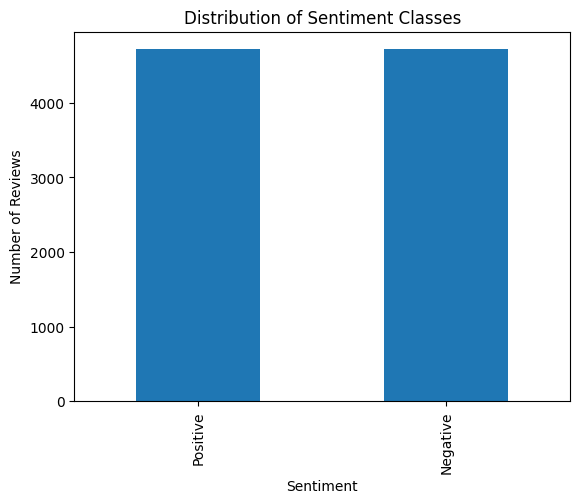

In [14]:
import matplotlib.pyplot as plt

balanced_df['Sentiment'].value_counts().plot(
    kind='bar'
)

plt.title('Distribution of Sentiment Classes')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

# Step 3: Text Preprocessing

## 3.1 Import NLP Libraries

In [15]:
import re
import nltk

from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

## 3.2 Select a Sample Review

In [16]:
sample_review = balanced_df['Review'].iloc[0]

print(sample_review)

I love what I'm learning and the way the teacher carries himself while explaining.


## 3.3 Lowercasing

In [17]:
lower_text = sample_review.lower()

print(lower_text)

i love what i'm learning and the way the teacher carries himself while explaining.


The text was converted to lowercase to ensure that words such as "Course" and "course" are treated as the same word during analysis.

## 3.4 Remove Punctuation and Special Characters

In [18]:
clean_text = re.sub(r'[^a-zA-Z\s]', '', lower_text)

print(clean_text)

i love what im learning and the way the teacher carries himself while explaining


Punctuation marks, numbers, and special characters were removed because they usually do not contribute meaningful information to sentiment classification.

## 3.5 Remove Extra Spaces

In [19]:
clean_text = re.sub(r'\s+', ' ', clean_text).strip()

print(clean_text)

i love what im learning and the way the teacher carries himself while explaining


## 3.6 Word Tokenization

In [20]:
word_tokens = word_tokenize(clean_text)

print(word_tokens)

['i', 'love', 'what', 'im', 'learning', 'and', 'the', 'way', 'the', 'teacher', 'carries', 'himself', 'while', 'explaining']


## 3.7 Sentence Tokenization

In [21]:
sentence_tokens = sent_tokenize(sample_review)

print(sentence_tokens)

["I love what I'm learning and the way the teacher carries himself while explaining."]


## 3.8 Stopword Removal

In [22]:
stop_words = set(stopwords.words('english'))

filtered_words = [
    word
    for word in word_tokens
    if word not in stop_words
]

print(filtered_words)

['love', 'im', 'learning', 'way', 'teacher', 'carries', 'explaining']


## 3.9 Stemming

In [23]:
stemmer = PorterStemmer()

stemmed_words = [
    stemmer.stem(word)
    for word in filtered_words
]

print(stemmed_words)

['love', 'im', 'learn', 'way', 'teacher', 'carri', 'explain']


## 3.10 Lemmatization

In [24]:
lemmatizer = WordNetLemmatizer()

lemmatized_words = [
    lemmatizer.lemmatize(word)
    for word in filtered_words
]

print(lemmatized_words)

['love', 'im', 'learning', 'way', 'teacher', 'carry', 'explaining']


**Text Preprocessing**

Text preprocessing was performed to clean and standardize the review text before converting it into numerical features. The preprocessing pipeline included lowercasing, removal of punctuation and special characters, removal of extra whitespace, tokenization, stopword removal, stemming, and lemmatization.

For example, the original review:

> "I love what I'm learning and the way the teacher carries himself while explaining."

After stopword removal, only the most meaningful words remained:

> love, im, learning, way, teacher, carries, explaining

The effects of stemming and lemmatization were also compared. Stemming reduced words to their root forms but sometimes produced incomplete words such as "carri". Lemmatization produced more meaningful dictionary words such as "carry". Therefore, lemmatization was selected for the final preprocessing pipeline used in model training.


##3.11: Create the Final Preprocessing Function

In [25]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    # lowercase
    text = text.lower()

    # remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = word_tokenize(text)

    # remove stopwords
    words = [word for word in words if word not in stop_words]

    # lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

## Applying Preprocessing to the Entire Dataset

In [26]:
balanced_df['Processed_Review'] = balanced_df['Review'].apply(preprocess_text)

Results

In [27]:
balanced_df[['Review','Processed_Review']].head()

,Review,Processed_Review
0,I love what I'm learning and the way the teach...,love im learning way teacher carry explaining
1,I learnt a lot of new information and I found ...,learnt lot new information found course conten...
2,Useful feature for Python!,useful feature python
3,"Nice course, really dynamic and well explained...",nice course really dynamic well explained real...
4,No teaching. Just a guy talking. Do the proble...,teaching guy talking problem set practice need...


# Step 4: Text Representation

## 4.1 Train-Test Split

Before vectorizing, split the data.

In [28]:
from sklearn.model_selection import train_test_split

X = balanced_df['Processed_Review']
y = balanced_df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(7552,)
(1888,)


## 4.2 Count Vectorizer (Bag of Words)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

count_vectorizer = CountVectorizer()

X_train_count = count_vectorizer.fit_transform(X_train)
X_test_count = count_vectorizer.transform(X_test)

print("Vocabulary Size:", len(count_vectorizer.vocabulary_))
print(X_train_count.shape)

Vocabulary Size: 12453
(7552, 12453)


In [30]:
list(count_vectorizer.vocabulary_.keys())[:20]

['good',
 'beginner',
 'strong',
 'interest',
 'learning',
 'mandarin',
 'chinese',
 'part',
 'course',
 'prof',
 'sytch',
 'derue',
 'really',
 'interesting',
 'important',
 'complete',
 'dr',
 'alexander',
 'impossible',
 'listen']

Count Vectorizer converts text into numerical features by counting the occurrence of each word in the document. Each unique word becomes a feature in the vocabulary.

## 4.3 TF-IDF Vectorizer

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Vocabulary Size:", len(tfidf_vectorizer.vocabulary_))
print(X_train_tfidf.shape)

Vocabulary Size: 12453
(7552, 12453)


TF-IDF (Term Frequency-Inverse Document Frequency) assigns higher importance to words that appear frequently in a document but are less common across the entire dataset. This helps reduce the influence of very common words.

**Step 4.4 N-gram Comparison**

Unigram

In [32]:
unigram_vectorizer = CountVectorizer(
    ngram_range=(1,1)
)

unigram_features = unigram_vectorizer.fit_transform(X_train)

print("Unigram Vocabulary Size:",
      len(unigram_vectorizer.vocabulary_))

Unigram Vocabulary Size: 12453


Bigram

In [33]:
bigram_vectorizer = CountVectorizer(
    ngram_range=(2,2)
)

bigram_features = bigram_vectorizer.fit_transform(X_train)

print("Bigram Vocabulary Size:",
      len(bigram_vectorizer.vocabulary_))

Bigram Vocabulary Size: 95250


Unigram + Bigram

In [34]:
unibigram_vectorizer = CountVectorizer(
    ngram_range=(1,2)
)

unibigram_features = unibigram_vectorizer.fit_transform(X_train)

print("Unigram + Bigram Vocabulary Size:",
      len(unibigram_vectorizer.vocabulary_))

Unigram + Bigram Vocabulary Size: 107703


Sample

In [35]:
list(bigram_vectorizer.vocabulary_.keys())[:20]

['good beginner',
 'beginner strong',
 'strong interest',
 'interest learning',
 'learning mandarin',
 'mandarin chinese',
 'part course',
 'course prof',
 'prof sytch',
 'sytch prof',
 'prof derue',
 'derue really',
 'really interesting',
 'interesting important',
 'important complete',
 'complete course',
 'course part',
 'part dr',
 'dr alexander',
 'alexander impossible']

## Step 4: Text Representation

After preprocessing, the text data was converted into numerical representations so that machine learning algorithms could process it.

### Count Vectorizer

Count Vectorizer was used to convert the text into a Bag-of-Words representation. Each unique word in the dataset became a feature, and the value of each feature represented the number of times the word appeared in a review. The resulting vocabulary contained 12,453 unique words.

### TF-IDF Vectorizer

TF-IDF (Term Frequency-Inverse Document Frequency) was also applied to the preprocessed reviews. While the vocabulary size remained the same as Count Vectorizer (12,453 features), TF-IDF assigns weights based on the importance of words rather than simple frequency counts. This helps reduce the influence of very common words and emphasizes more informative terms.

### N-Gram Analysis

Different N-gram settings were explored to understand how vocabulary changes when contextual information is included.

| N-Gram Type      | Vocabulary Size |
| ---------------- | --------------- |
| Unigram          | 12,453          |
| Bigram           | 95,250          |
| Unigram + Bigram | 107,703         |

The results show that the vocabulary size increases significantly when bigrams are included because every unique two-word combination becomes a separate feature. Examples of extracted bigrams include "good beginner", "mandarin chinese", "really interesting", and "complete course".

N-grams help preserve context that may be lost when using individual words alone, making them useful for text classification tasks.


# Step 5: Train Machine Learning Models

## Model 1: Naive Bayes (Count Vectorizer)

In [36]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train_count, y_train)

nb_pred = nb_model.predict(X_test_count)

print("Accuracy:",
      accuracy_score(y_test, nb_pred))

Accuracy: 0.8797669491525424


## Model 2: Logistic Regression (TF-IDF)

In [37]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

Accuracy: 0.8914194915254238


In [38]:
import pandas as pd
import numpy as np

feature_names = tfidf_vectorizer.get_feature_names_out()

coefficients = lr_model.coef_[0]

top_positive = np.argsort(coefficients)[-10:]
top_negative = np.argsort(coefficients)[:10]

print("Top Positive Words:")
for idx in reversed(top_positive):
    print(feature_names[idx])

print("\nTop Negative Words:")
for idx in top_negative:
    print(feature_names[idx])

Top Positive Words:
great
excellent
thank
good
enjoyed
awesome
love
nice
thanks
best

Top Negative Words:
boring
poor
dont
didnt
doesnt
content
bad
poorly
disappointed
anything


Important Features Learned by Logistic Regression

To better understand how the model makes predictions, the most influential words learned by the Logistic Regression classifier were examined. Words with the highest positive coefficients contribute more strongly to the Positive class, while words with the lowest coefficients are associated with the Negative class.

The results showed that positive reviews frequently contained words related to satisfaction, usefulness, and recommendation, whereas negative reviews often contained words expressing dissatisfaction, confusion, or poor learning experiences. This analysis helps explain why the model was able to distinguish between positive and negative student feedback with high accuracy.

##Model 3: Support Vector Machine (TF-IDF)

In [39]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print("Accuracy:",
      accuracy_score(y_test, svm_pred))

Accuracy: 0.8797669491525424


Logistic Regression + TF-IDF performed the best with an accuracy of 89.14%.
Naive Bayes and SVM achieved very similar results at 87.98%.
The results suggest that TF-IDF weighting helped Logistic Regression better identify important words and distinguish between positive and negative reviews.

# Step 6: Model Evaluation

## Naive Bayes Evaluation

In [40]:
from sklearn.metrics import classification_report

print("Naive Bayes")
print(classification_report(y_test, nb_pred))

Naive Bayes
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88       944
    Positive       0.89      0.87      0.88       944

    accuracy                           0.88      1888
   macro avg       0.88      0.88      0.88      1888
weighted avg       0.88      0.88      0.88      1888



## Logistic Regression Evaluation

In [41]:
print("Logistic Regression")
print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

    Negative       0.88      0.91      0.89       944
    Positive       0.91      0.87      0.89       944

    accuracy                           0.89      1888
   macro avg       0.89      0.89      0.89      1888
weighted avg       0.89      0.89      0.89      1888



## SVM Evaluation

In [42]:
print("SVM")
print(classification_report(y_test, svm_pred))

SVM
              precision    recall  f1-score   support

    Negative       0.87      0.89      0.88       944
    Positive       0.89      0.87      0.88       944

    accuracy                           0.88      1888
   macro avg       0.88      0.88      0.88      1888
weighted avg       0.88      0.88      0.88      1888



## Confusion Matrix for Best Model

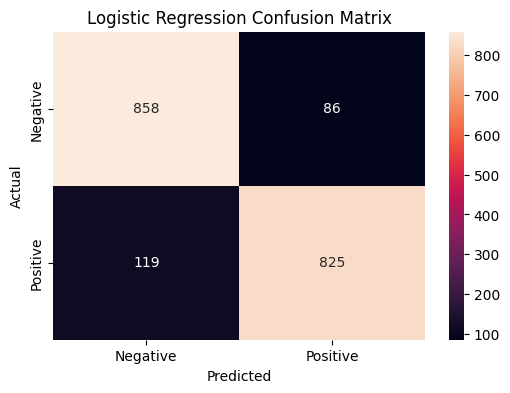

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

| Model               | Representation   | Accuracy | Precision | Recall | F1-Score |
| ------------------- | ---------------- | -------- | --------- | ------ | -------- |
| Naive Bayes         | Count Vectorizer | 0.88     | 0.88      | 0.88   | 0.88     |
| Logistic Regression | TF-IDF           | 0.89     | 0.89      | 0.89   | 0.89     |
| SVM                 | TF-IDF           | 0.88     | 0.88      | 0.88   | 0.88     |


Three machine learning classifiers were trained and evaluated using different text representations. The performance of each model was measured using Accuracy, Precision, Recall, and F1-Score.

The results show that all three models performed well on the balanced student feedback dataset. Logistic Regression achieved the highest accuracy of 89.14% and also obtained the best Precision, Recall, and F1-Score values. This suggests that Logistic Regression was able to learn meaningful patterns from the TF-IDF features and classify student reviews more effectively than the other models.

Naive Bayes and Support Vector Machine achieved similar performance with an accuracy of approximately 88%. Although their performance was slightly lower than Logistic Regression, both models demonstrated strong classification capabilities and produced balanced Precision and Recall scores.

The overall results indicate that TF-IDF is an effective text representation technique for sentiment classification because it highlights important words while reducing the influence of common terms. Among the evaluated models, Logistic Regression combined with TF-IDF provided the best overall performance.

## **Word Cloud**

In [44]:
!pip install wordcloud

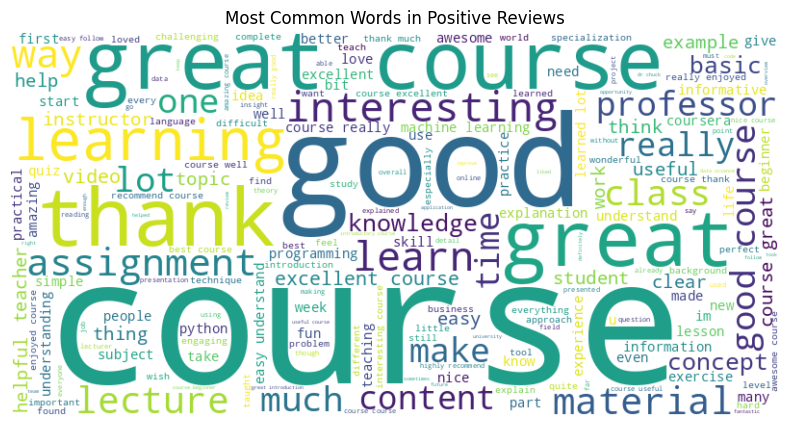

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(
    balanced_df[balanced_df['Sentiment'] == 'Positive']['Processed_Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Reviews')
plt.show()

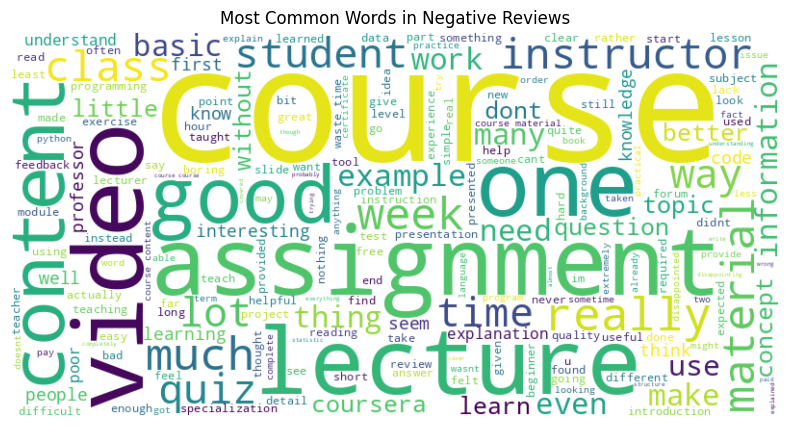

In [46]:
negative_text = " ".join(
    balanced_df[balanced_df['Sentiment'] == 'Negative']['Processed_Review']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Reviews')
plt.show()

### Word Cloud Visualization

Word clouds were generated to visualize the most frequently occurring words in positive and negative student reviews. Larger words represent terms that appeared more often in the corresponding sentiment category.

The positive review word cloud highlighted words associated with satisfaction, learning, and course quality. In contrast, the negative review word cloud emphasized words related to confusion, difficulty, and dissatisfaction. These visualizations provide an intuitive understanding of the language patterns present in student feedback.


# Step 7: N-Gram and Markov Model Understanding

## What is a Unigram?
A unigram is a single word treated as an individual feature. For example, the sentence "I love learning NLP" contains the unigrams: I, love, learning, and NLP.

## What is a Bigram?
A bigram is a sequence of two consecutive words. For example, the sentence "I love learning NLP" contains the bigrams: "I love", "love learning", and "learning NLP".

## What is a Trigram?
A trigram is a sequence of three consecutive words. For example, the sentence "I love learning NLP" contains the trigram "I love learning".

## How Are N-Grams Related to Markov Models?
N-grams are related to Markov models because they use previous words to estimate the likelihood of the next word. Bigrams use one previous word, while trigrams use two previous words to capture context.

## How Can N-Grams Improve Text Classification?
N-grams help preserve context that may be lost when considering individual words separately. For example, the phrase "highly recommend" carries stronger meaning than the individual words "highly" and "recommend". This additional context can improve classification performance.

# Conclusion

In this project, I developed a Student Feedback Classification system using Natural Language Processing (NLP) and machine learning techniques. I used a dataset of student course reviews and converted the original ratings into positive and negative sentiment categories to create a binary classification problem.

To prepare the data for analysis, I applied several text preprocessing techniques, including lowercasing, punctuation removal, tokenization, stopword removal, stemming, and lemmatization. These steps helped clean and standardize the text, making it more suitable for machine learning. I then transformed the processed text into numerical features using Count Vectorizer, TF-IDF, and N-gram representations.

To evaluate different approaches, I trained and tested three machine learning models: Naive Bayes, Logistic Regression, and Support Vector Machine (SVM). Among these models, Logistic Regression combined with TF-IDF achieved the best performance, with an accuracy of 89.14%. This indicates that TF-IDF was effective in highlighting the most informative words in the reviews and improving classification performance.

Through this project, I gained practical experience in the complete NLP workflow, from preprocessing raw text data to feature extraction, model training, and evaluation. The results demonstrate that NLP techniques can effectively analyze student feedback and automatically identify positive and negative sentiments. Such systems can help educational institutions better understand student opinions and make data-driven improvements to courses and teaching practices.

